# Summary Plot Example

This notebook demonstrates the `summary_plot()` function and its individual panel components. The summary dashboard provides a compact, high-level overview of somatic variants in a cohort, answering key questions about the mutational landscape.

For detailed documentation, see the [Summary Plot API Reference](https://luisruimor.github.io/pyMut/api/Visualization/summary_plot/).

## Load Data

Load the MAF file and create a `PyMutation` object. The example uses the TCGA-LAML dataset.

In [1]:
from pyMut.input import read_maf

maf_path = "../../../src/pyMut/data/examples/MAF/tcga_laml.maf.gz"
print(f'📂 Loading file: {maf_path}')

# Read the MAF file and create the PyMutation object
py_mutation = read_maf(maf_path,assembly="37")

2026-01-12 20:26:51,800 | INFO | pyMut.input | Starting MAF reading: ../../../src/pyMut/data/examples/MAF/tcga_laml.maf.gz
2026-01-12 20:26:51,801 | INFO | pyMut.input | Loading from cache: ../../../src/pyMut/data/examples/MAF/.pymut_cache/tcga_laml.maf_b418f48ee3247f26.parquet
2026-01-12 20:26:51,832 | INFO | pyMut.input | Cache loaded successfully in 0.03 seconds


📂 Loading file: ../../../src/pyMut/data/examples/MAF/tcga_laml.maf.gz


## Configure Plot Settings

Enable high-quality rendering settings for publication-ready figures.

In [2]:
py_mutation.configure_high_quality_plots()

## Full Summary Dashboard

The `summary_plot()` function generates a six-panel dashboard combining sample-level, gene-level, and cohort-level views.

**Parameters:**

- `figsize`: Figure size as (width, height) in inches. Default: `(16, 12)`
- `title`: Main title for the plot. Default: `"Mutation Summary"`
- `max_samples`: Maximum samples to display in the variants per sample panel. Default: `200`
- `top_genes_count`: Number of top genes to show. Default: `10`

2026-01-12 20:27:51,934 | INFO | pyMut.core | Generating summary plot...
2026-01-12 20:27:59,564 | INFO | pyMut.core | Summary plot generated in 7.63 seconds


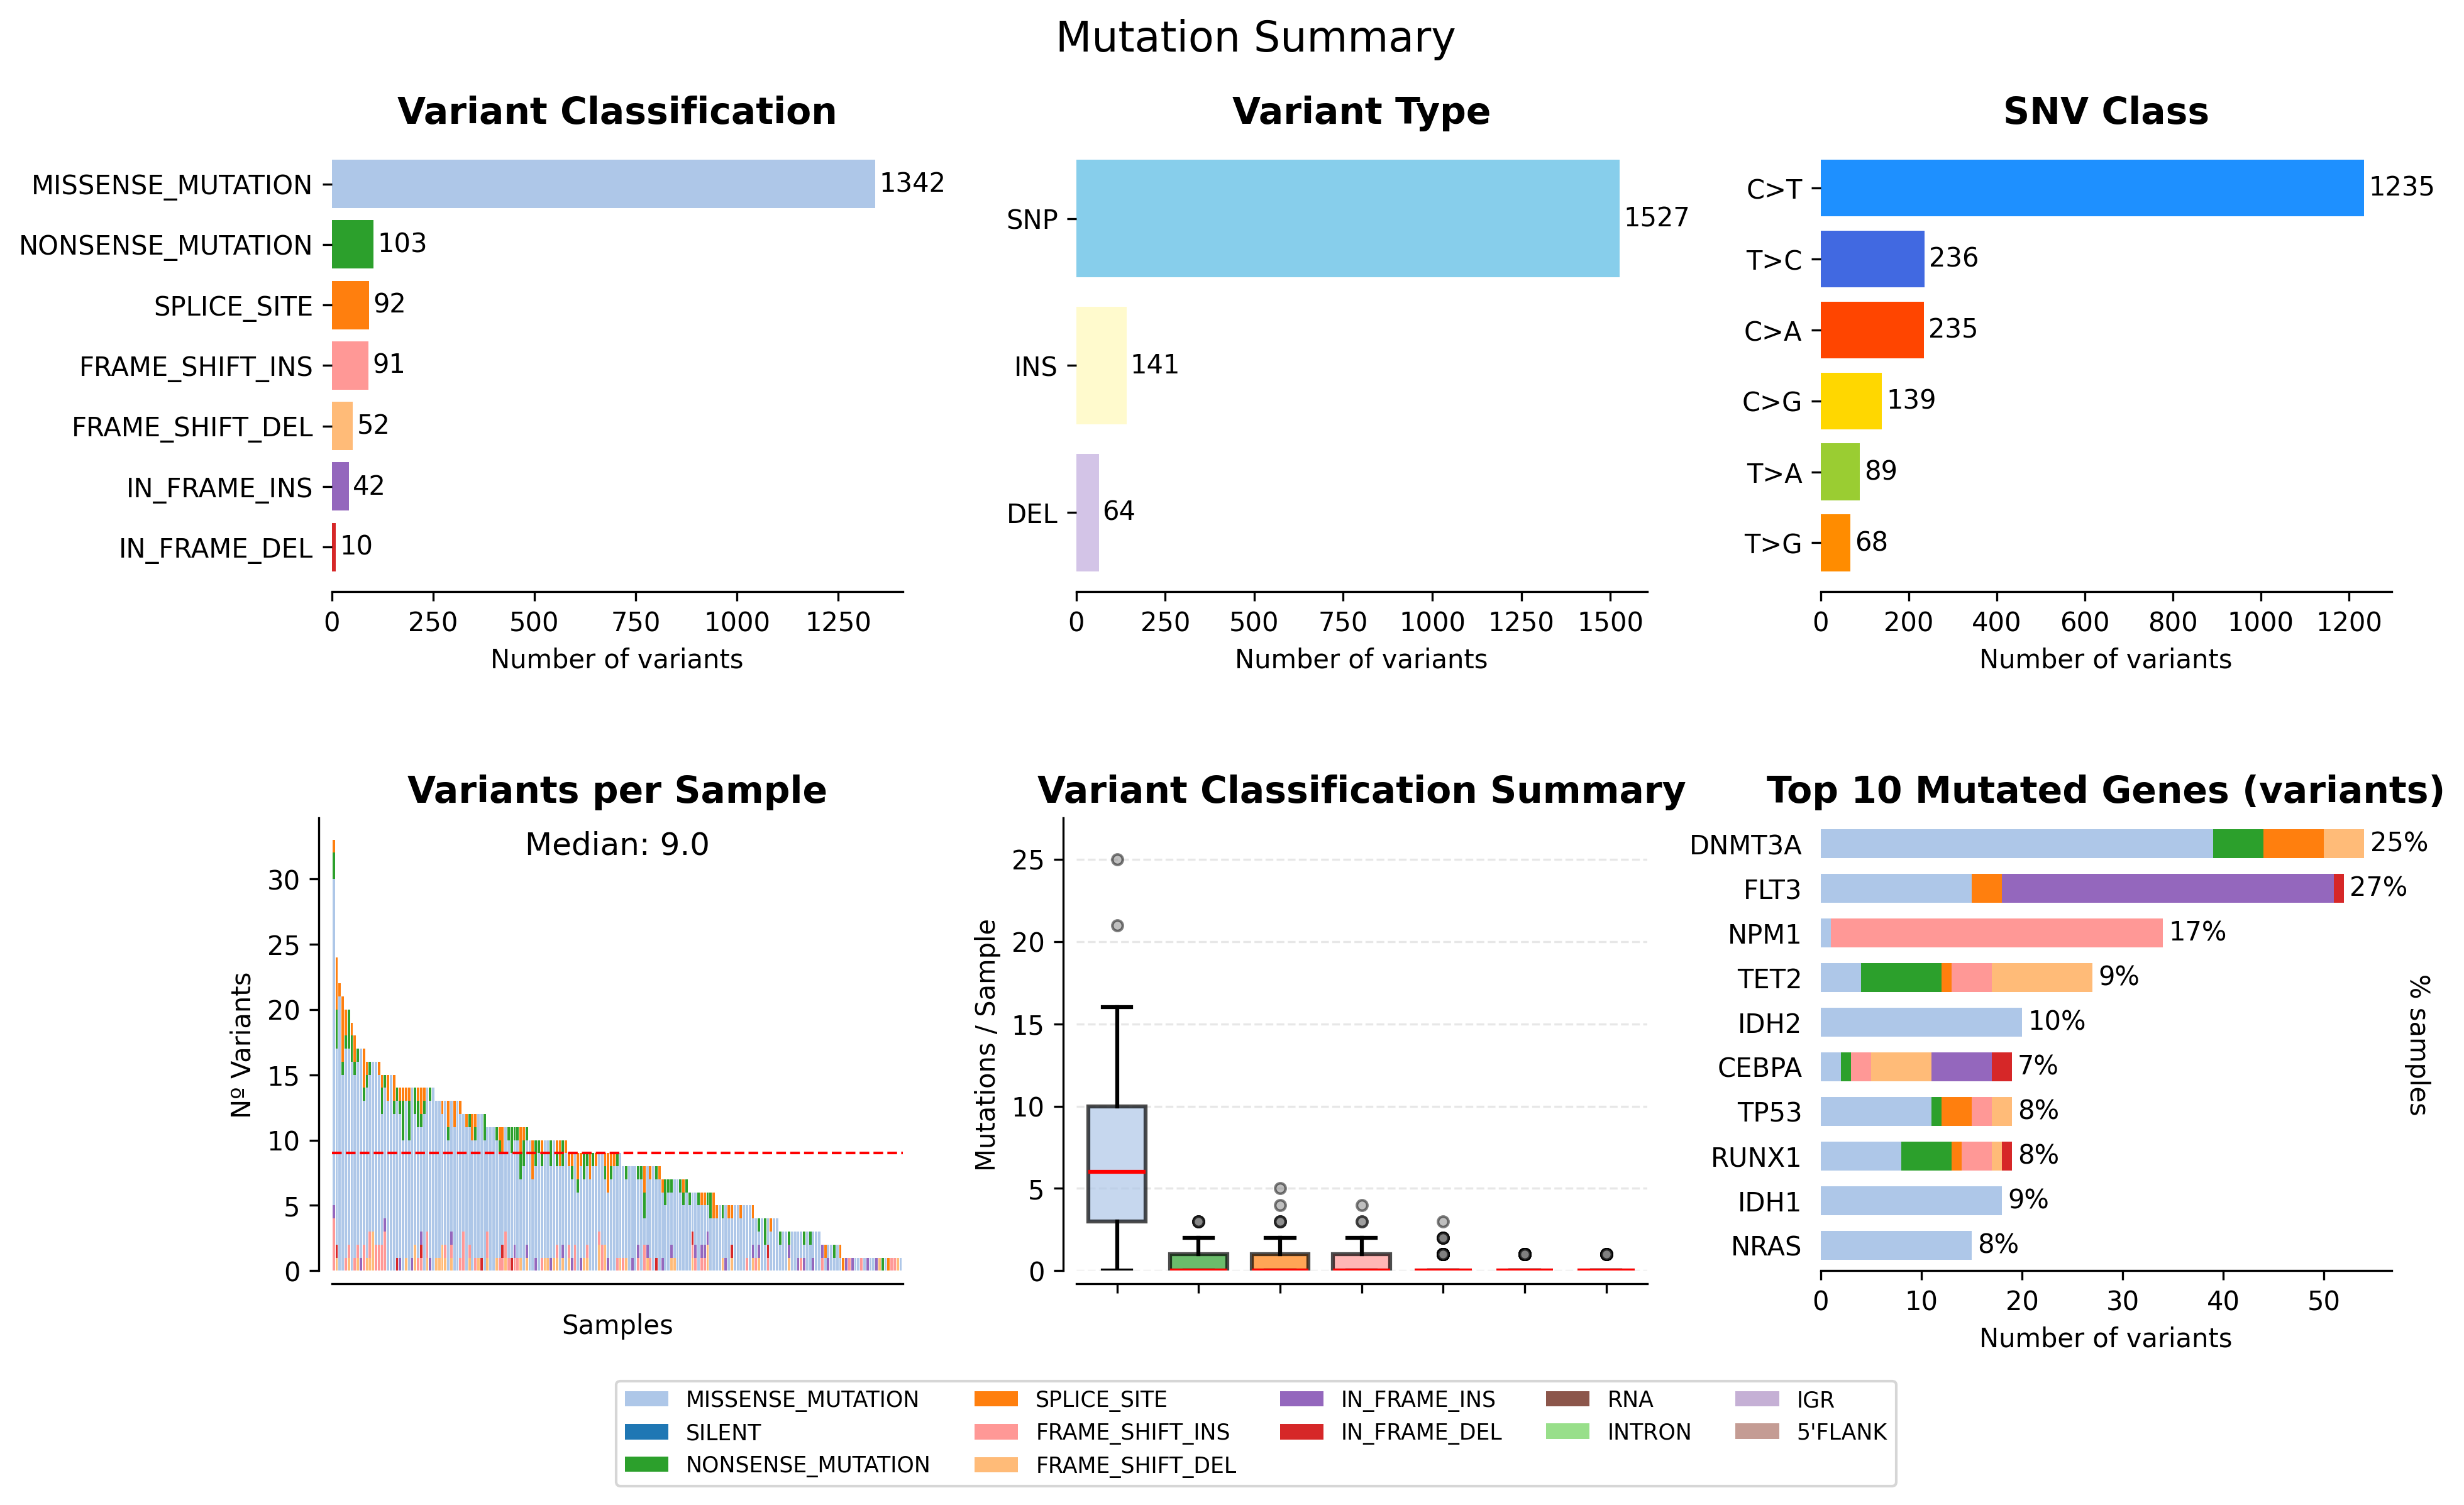

In [11]:
py_mutation.summary_plot()

## Individual Panel Components

Each panel from the summary dashboard is also available as a standalone function.

### Variant Classification

Horizontal barplot showing the distribution of variant classifications (e.g., Missense_Mutation, Nonsense_Mutation). Bars are sorted by frequency and annotated with counts.

**Parameters:**

- `figsize`: Figure size. Default: `(10, 6)`
- `title`: Plot title. Default: `"Variant Classification"`

2026-01-12 20:27:13,862 | INFO | pyMut.core | Generating variant classification plot...
2026-01-12 20:27:14,438 | INFO | pyMut.core | Variant classification plot generated in 0.58 seconds


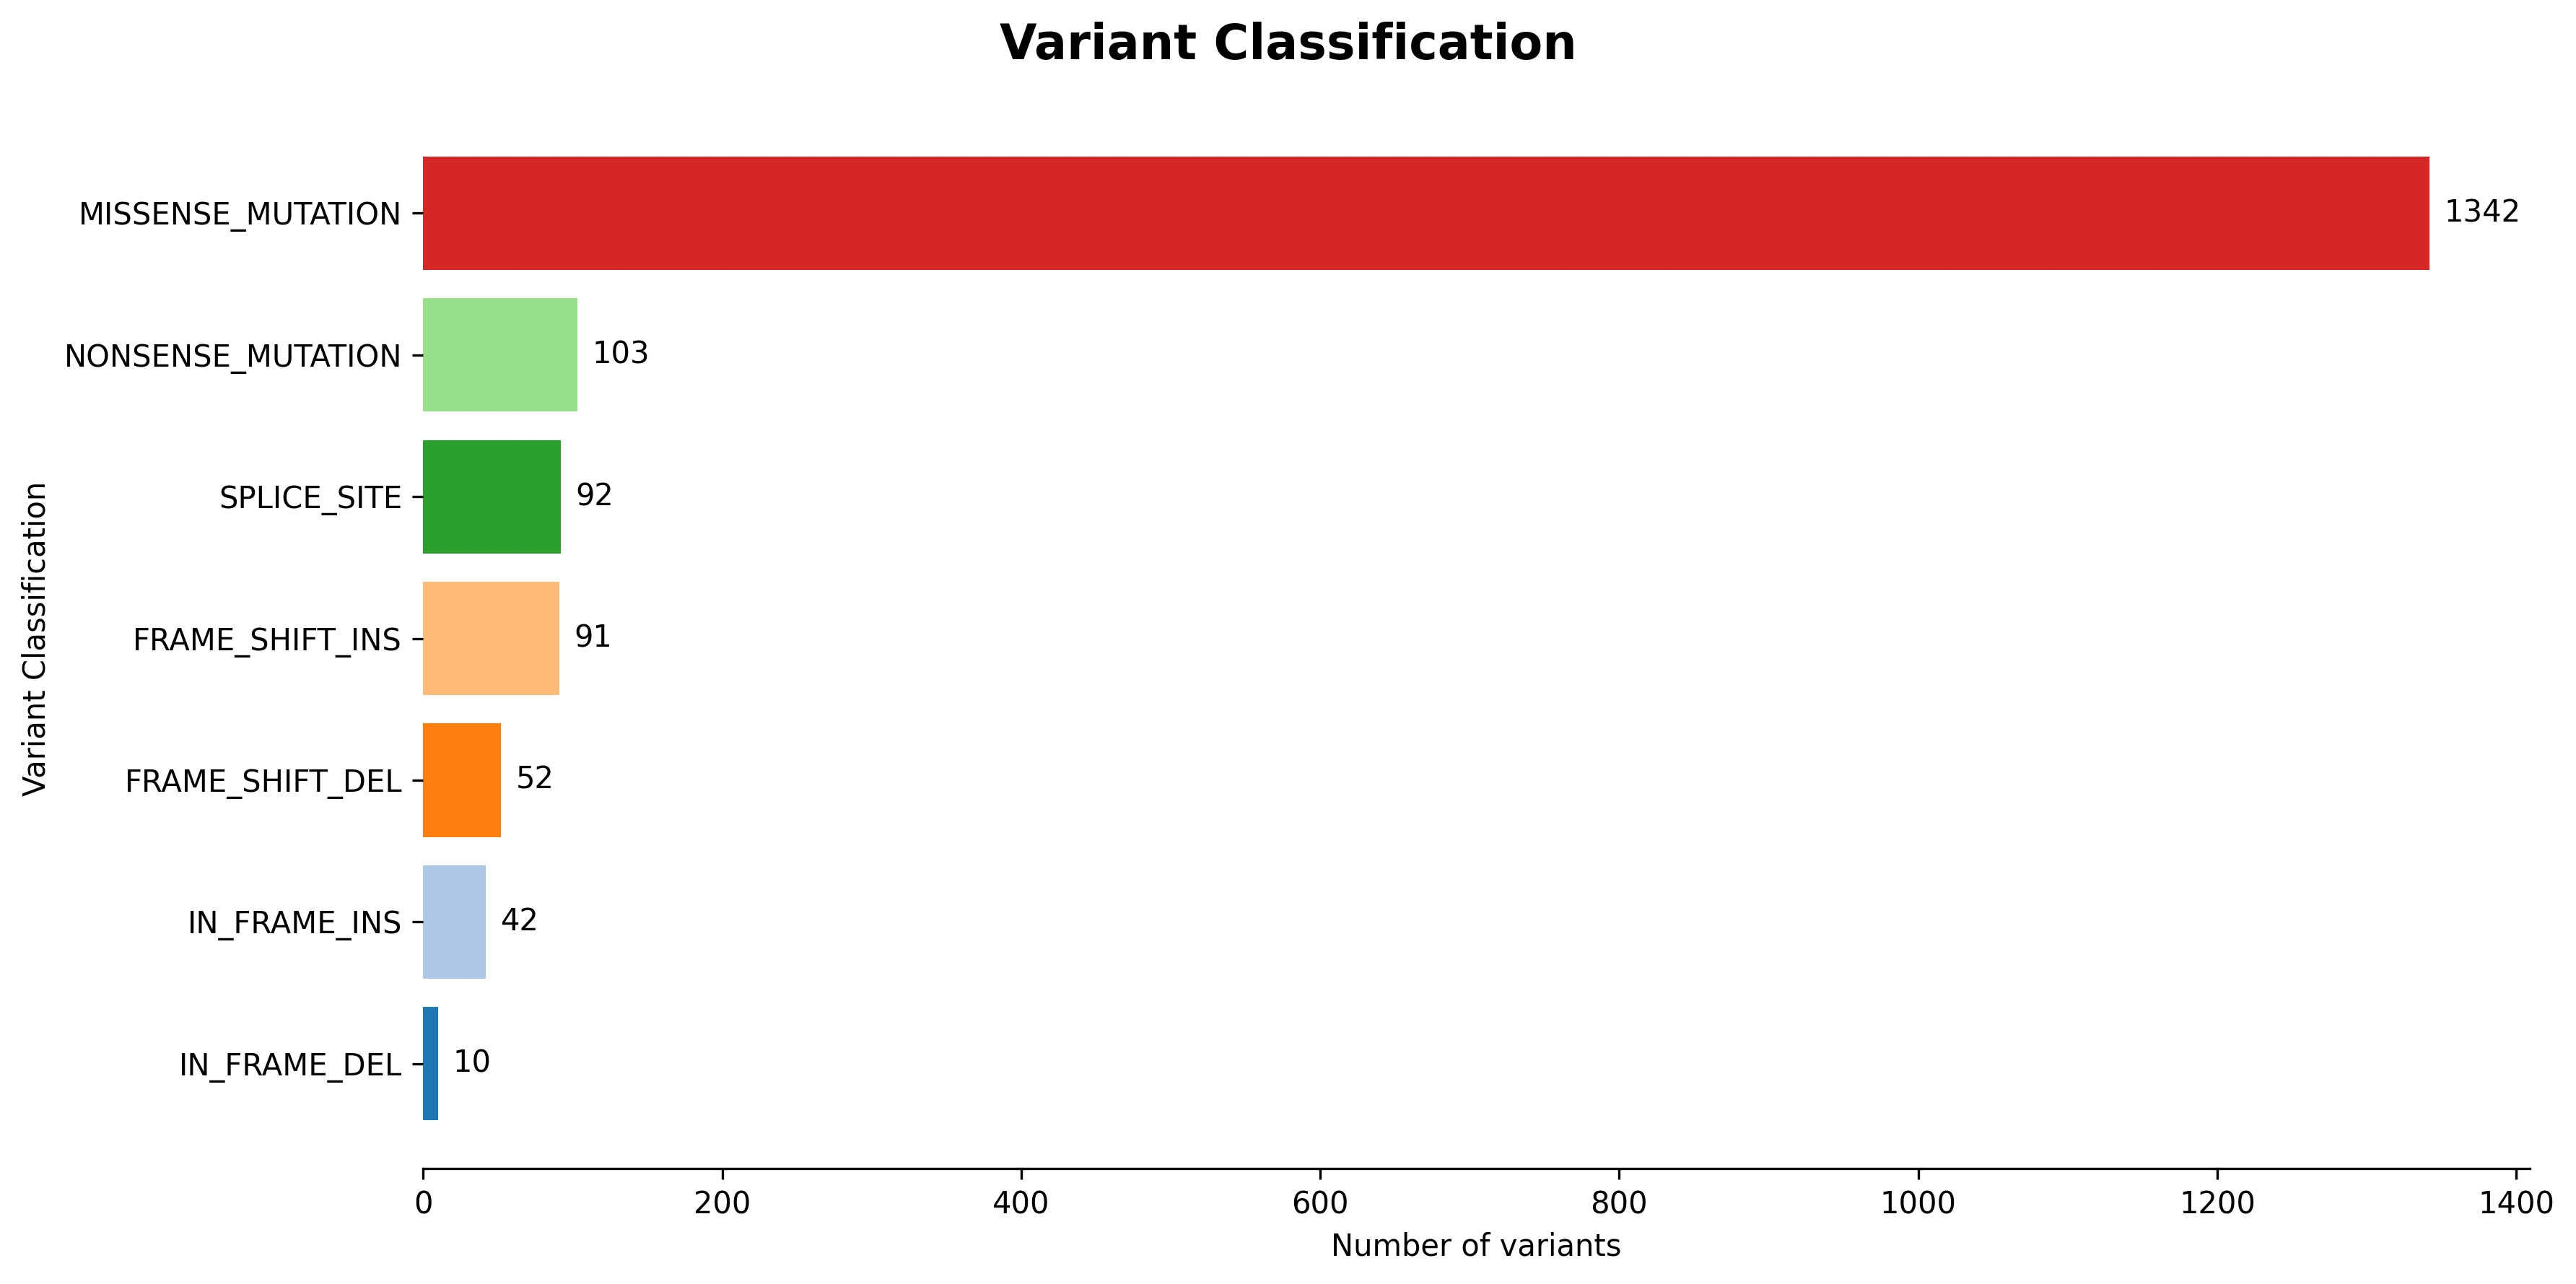

In [5]:
py_mutation.variant_classification_plot()

**Note:** By default, silent (synonymous) mutations and non-coding variants are excluded. This shows only protein-altering variants. Use `include_silent=True` to include all variants.

### Variant Type

Horizontal barplot summarizing structural variant types (SNP, INS, DEL). Bars are sorted by frequency and annotated with counts.

**Parameters:**

- `figsize`: Figure size. Default: `(10, 6)`
- `title`: Plot title. Default: `"Variant Type"`

2026-01-12 20:27:15,293 | INFO | pyMut.core | Generating variant type plot...
2026-01-12 20:27:15,860 | INFO | pyMut.core | Variant type plot generated in 0.57 seconds


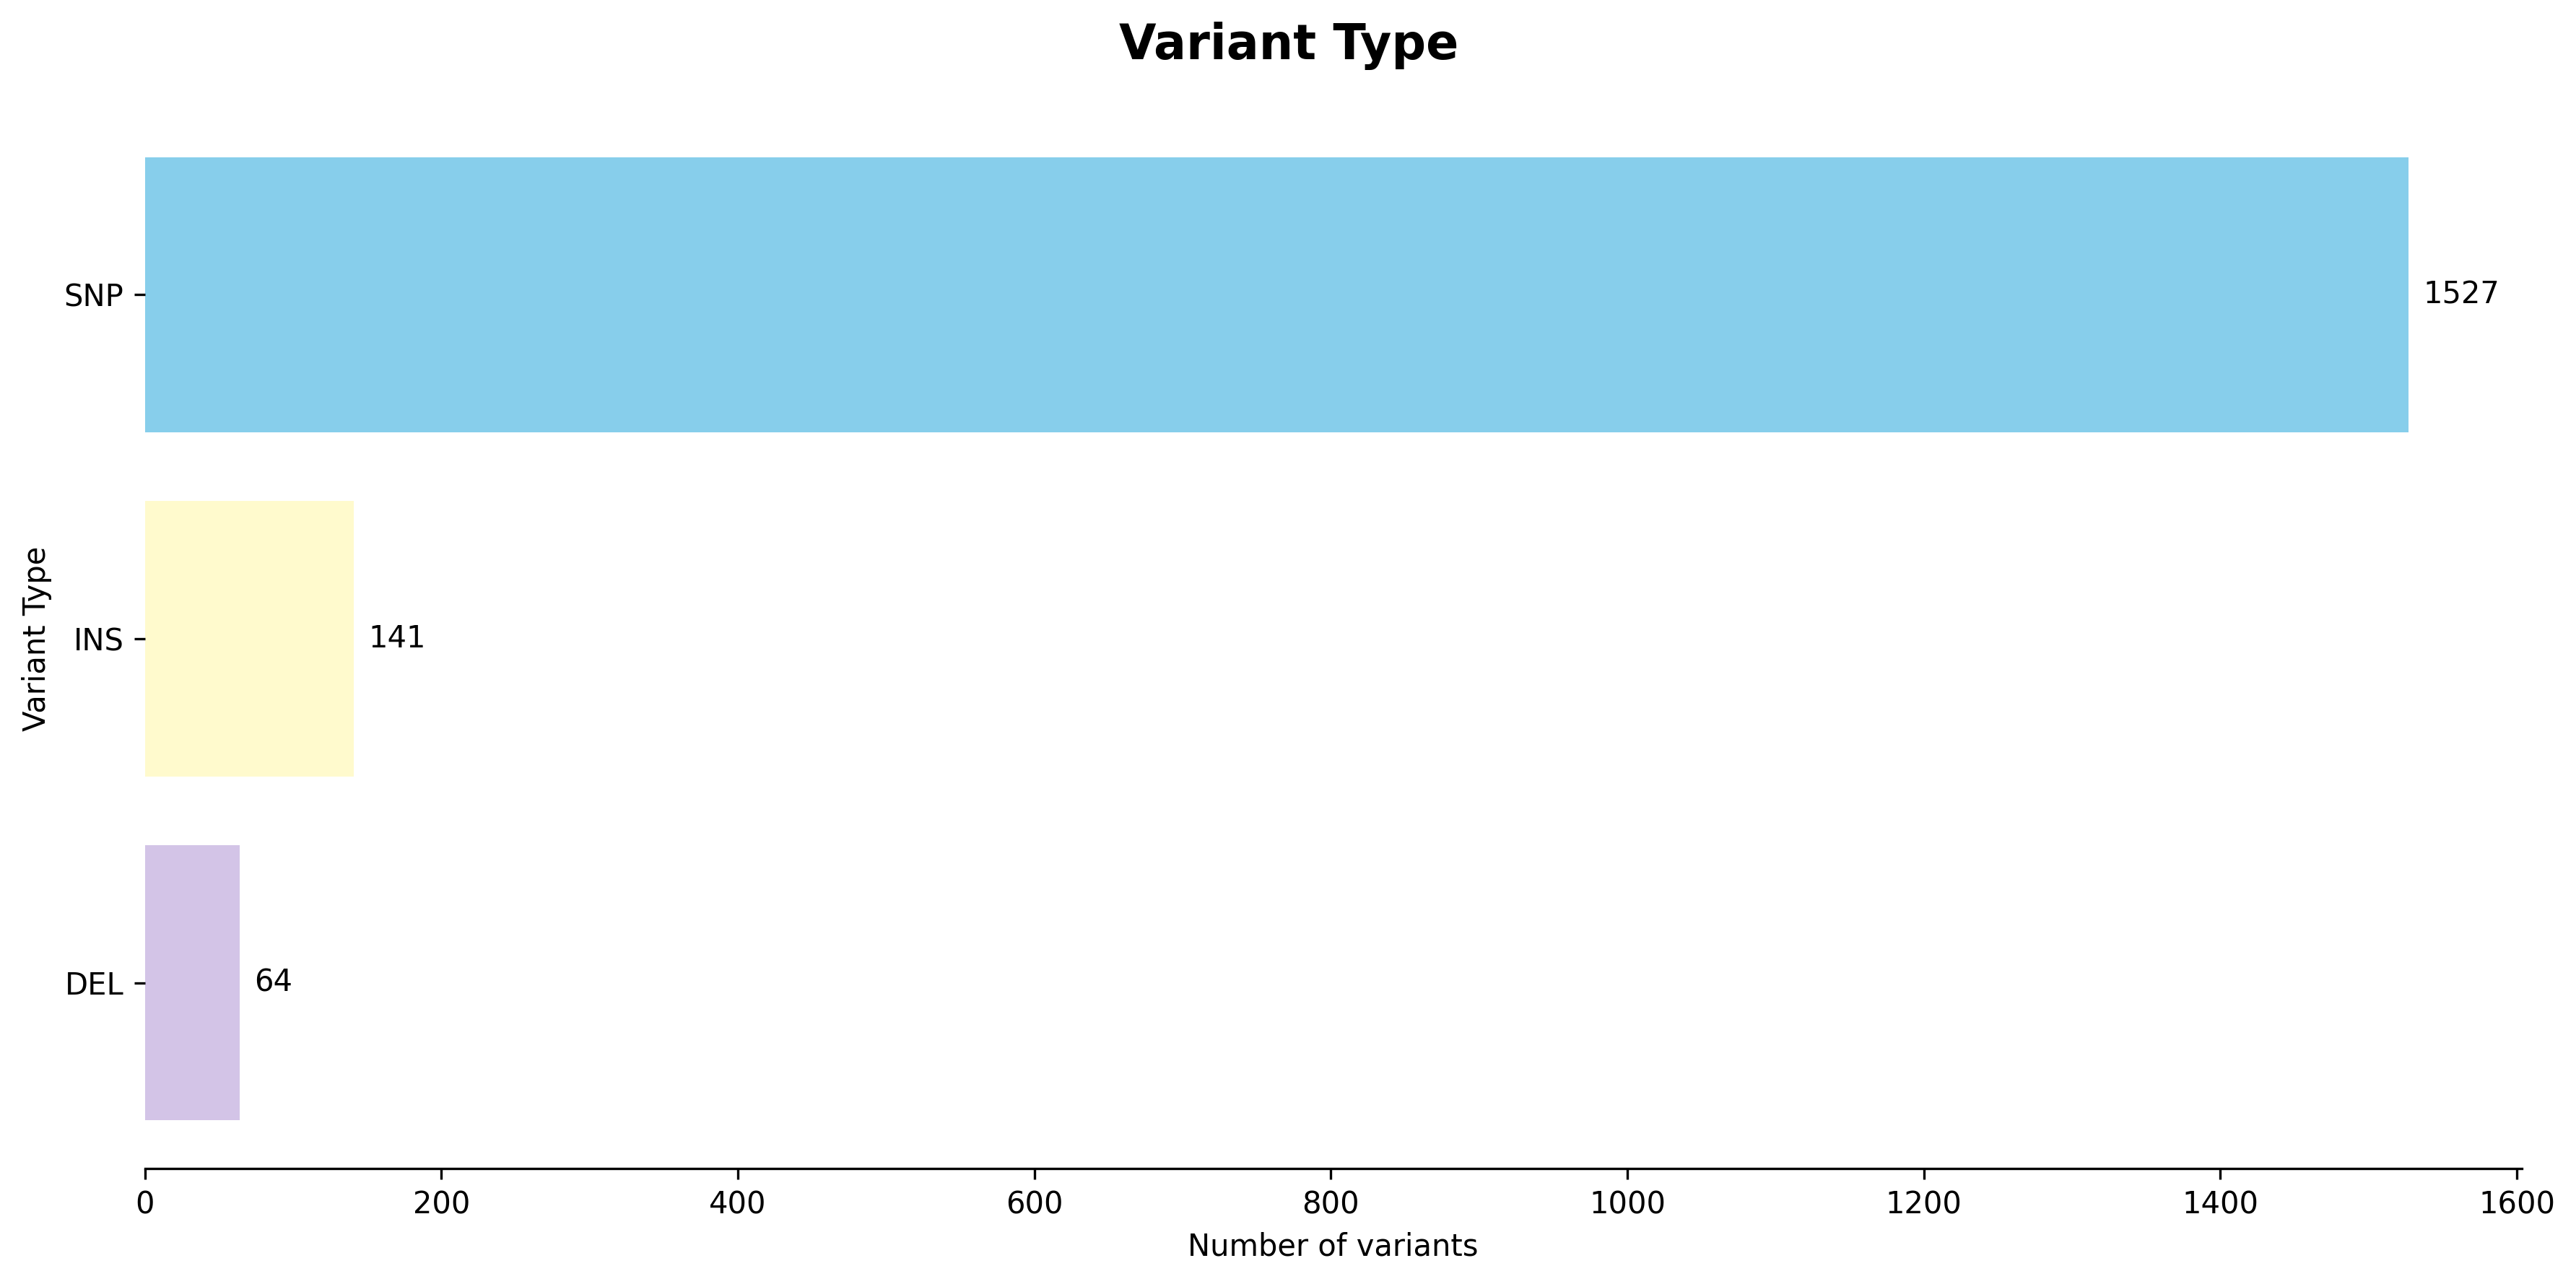

In [7]:
py_mutation.variant_type_plot()

**Note:** Like the variant classification plot, this also excludes silent mutations by default. Use `include_silent=True` to include all variants.

### SNV Class

Horizontal barplot showing single-nucleotide variant substitution classes (e.g., C>T, G>A). By default, normalizes to pyrimidine context (C or T as reference).

**Parameters:**

- `figsize`: Figure size. Default: `(10, 6)`
- `title`: Plot title. Default: `"SNV Class"`
- `ref_column`: Column containing reference alleles. Default: `"REF"`
- `alt_column`: Column containing alternative alleles. Default: `"ALT"`

2026-01-12 20:27:16,634 | INFO | pyMut.core | Generating SNV class plot...
2026-01-12 20:27:17,308 | INFO | pyMut.core | SNV class plot generated in 0.67 seconds


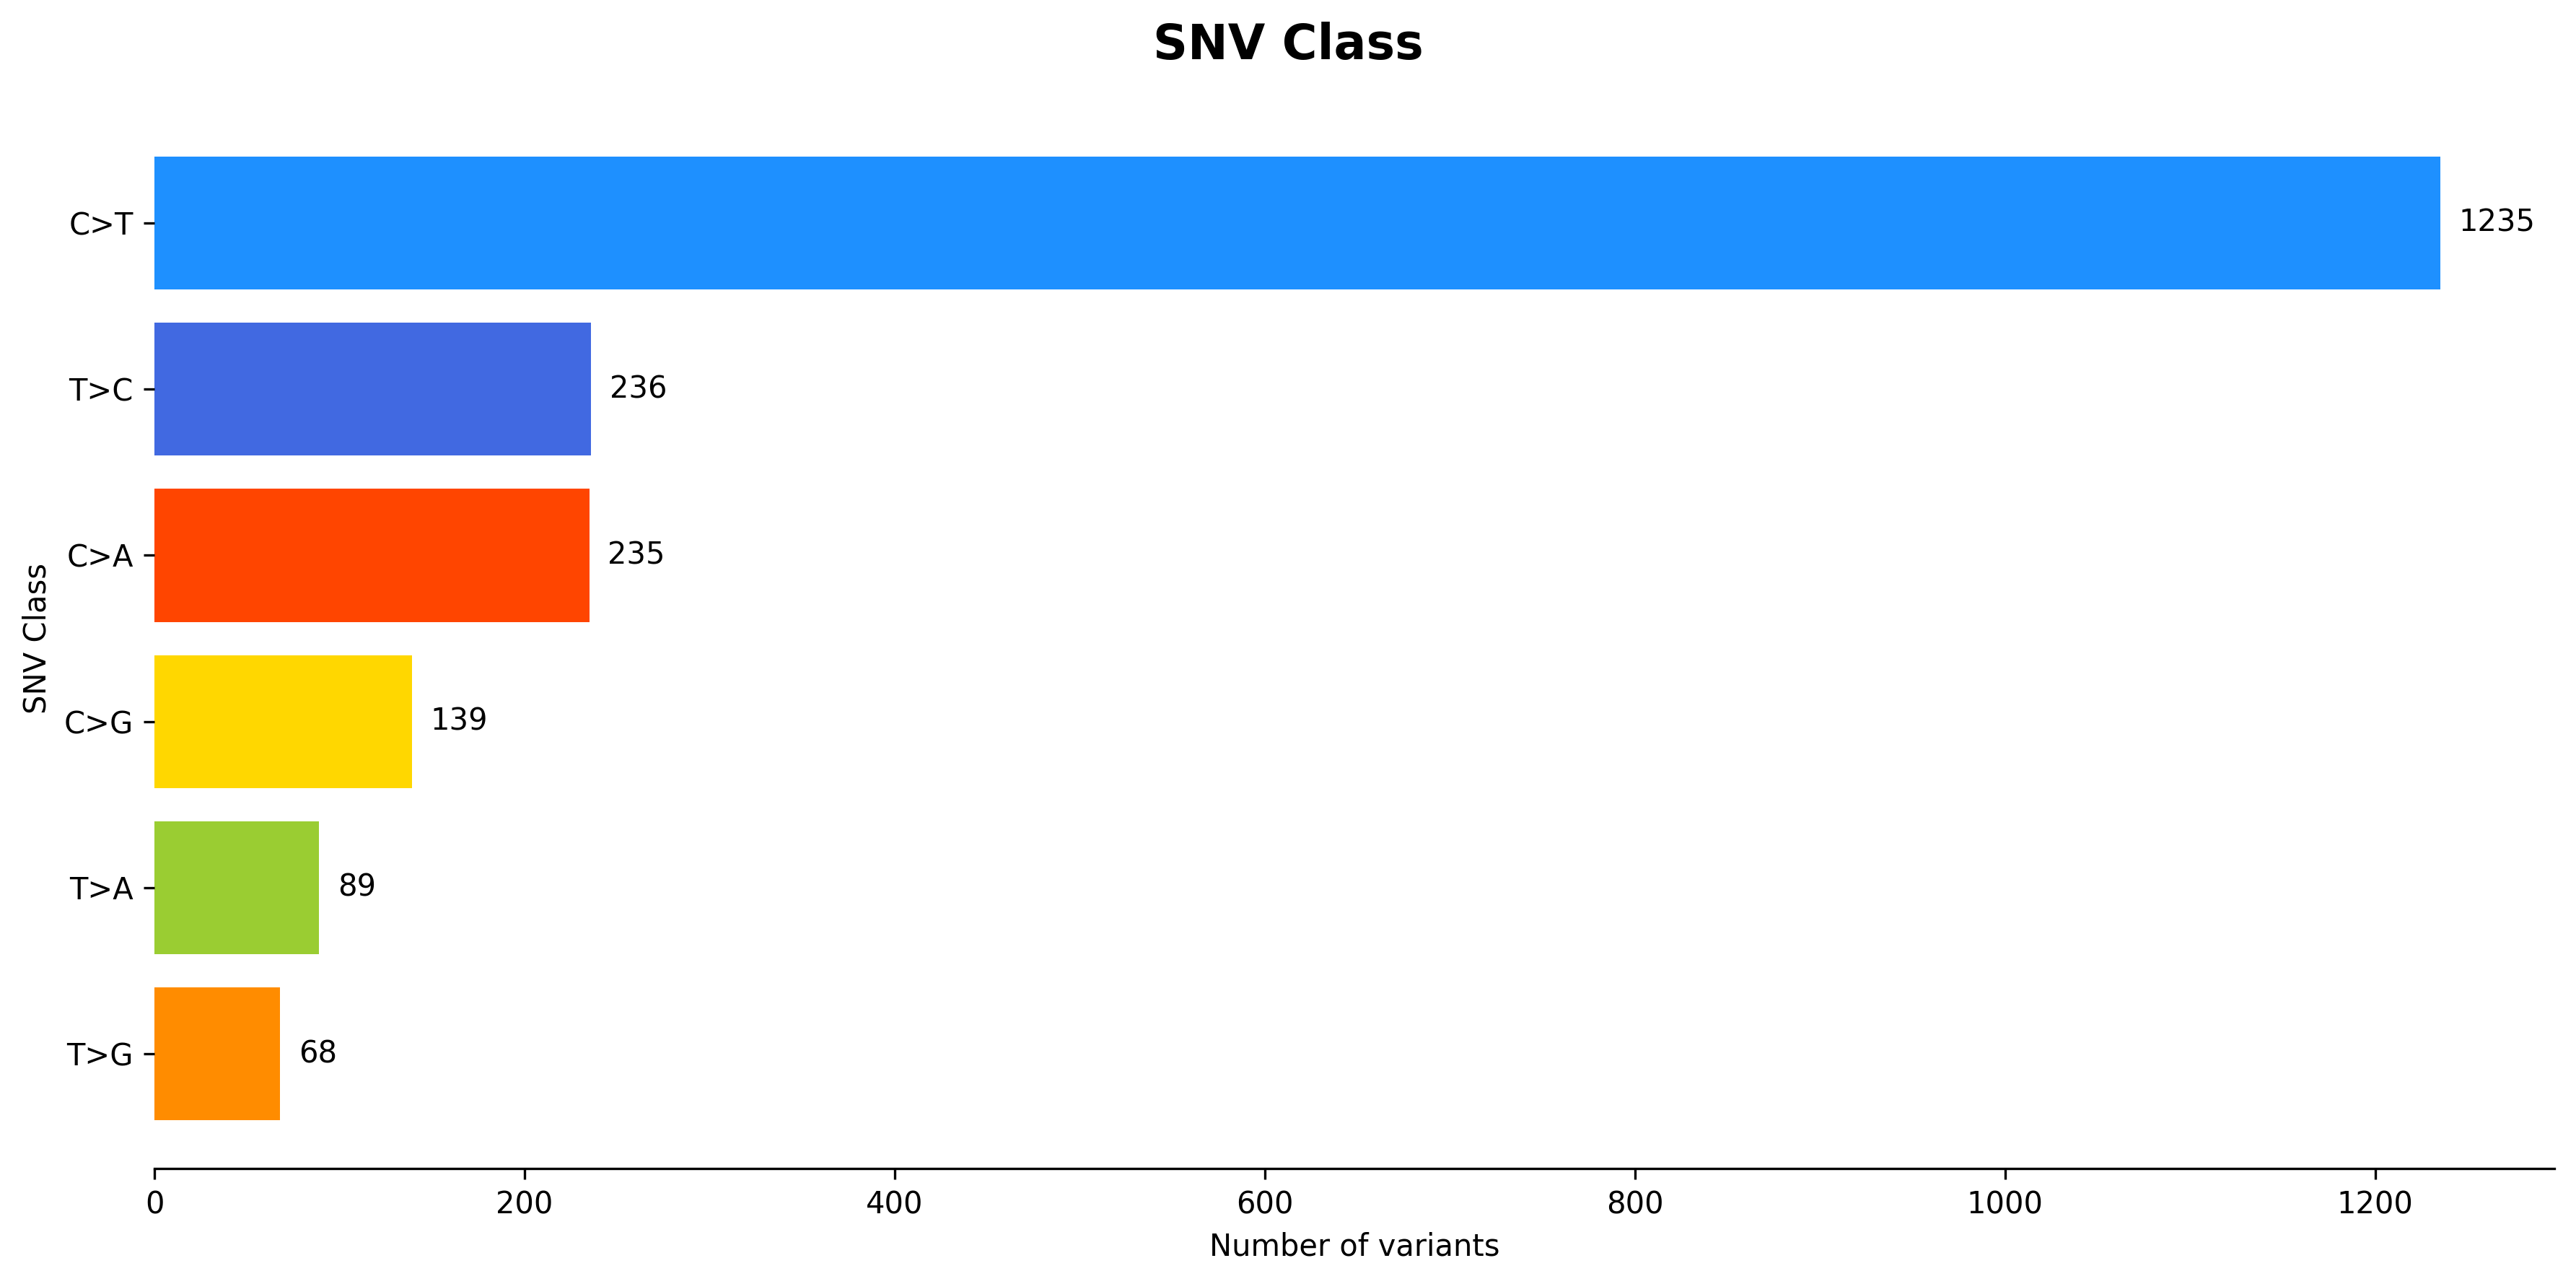

In [9]:
py_mutation.snv_class_plot()

**Note:** By default, mutations are normalized to pyrimidine bases (C or T as reference), converting purine mutations to their complement (e.g., A>C becomes T>G, G>A becomes C>T). This shows 6 canonical substitution classes (C>A, C>G, C>T, T>A, T>C, T>G), which follows maftools convention and mutational signature analysis standards. **Unlike other plots, this includes silent mutations** to show the complete SNV spectrum. Use `normalize_pyrimidine=False` to see all 12 possible substitution types.

### Variants per Sample

Stacked barplot showing the number of variants per sample, sorted by total count. The red dashed line indicates the median variant count across all samples.

**Parameters:**

- `figsize`: Figure size. Default: `(12, 6)`
- `title`: Plot title. Default: `"Variants per Sample"`
- `max_samples`: Maximum number of samples to display. Default: `None` (all samples)

2026-01-12 20:06:51,396 | INFO | pyMut.core | Generating variants per sample plot...
2026-01-12 20:06:52,391 | INFO | pyMut.core | Variants per sample plot generated in 0.99 seconds


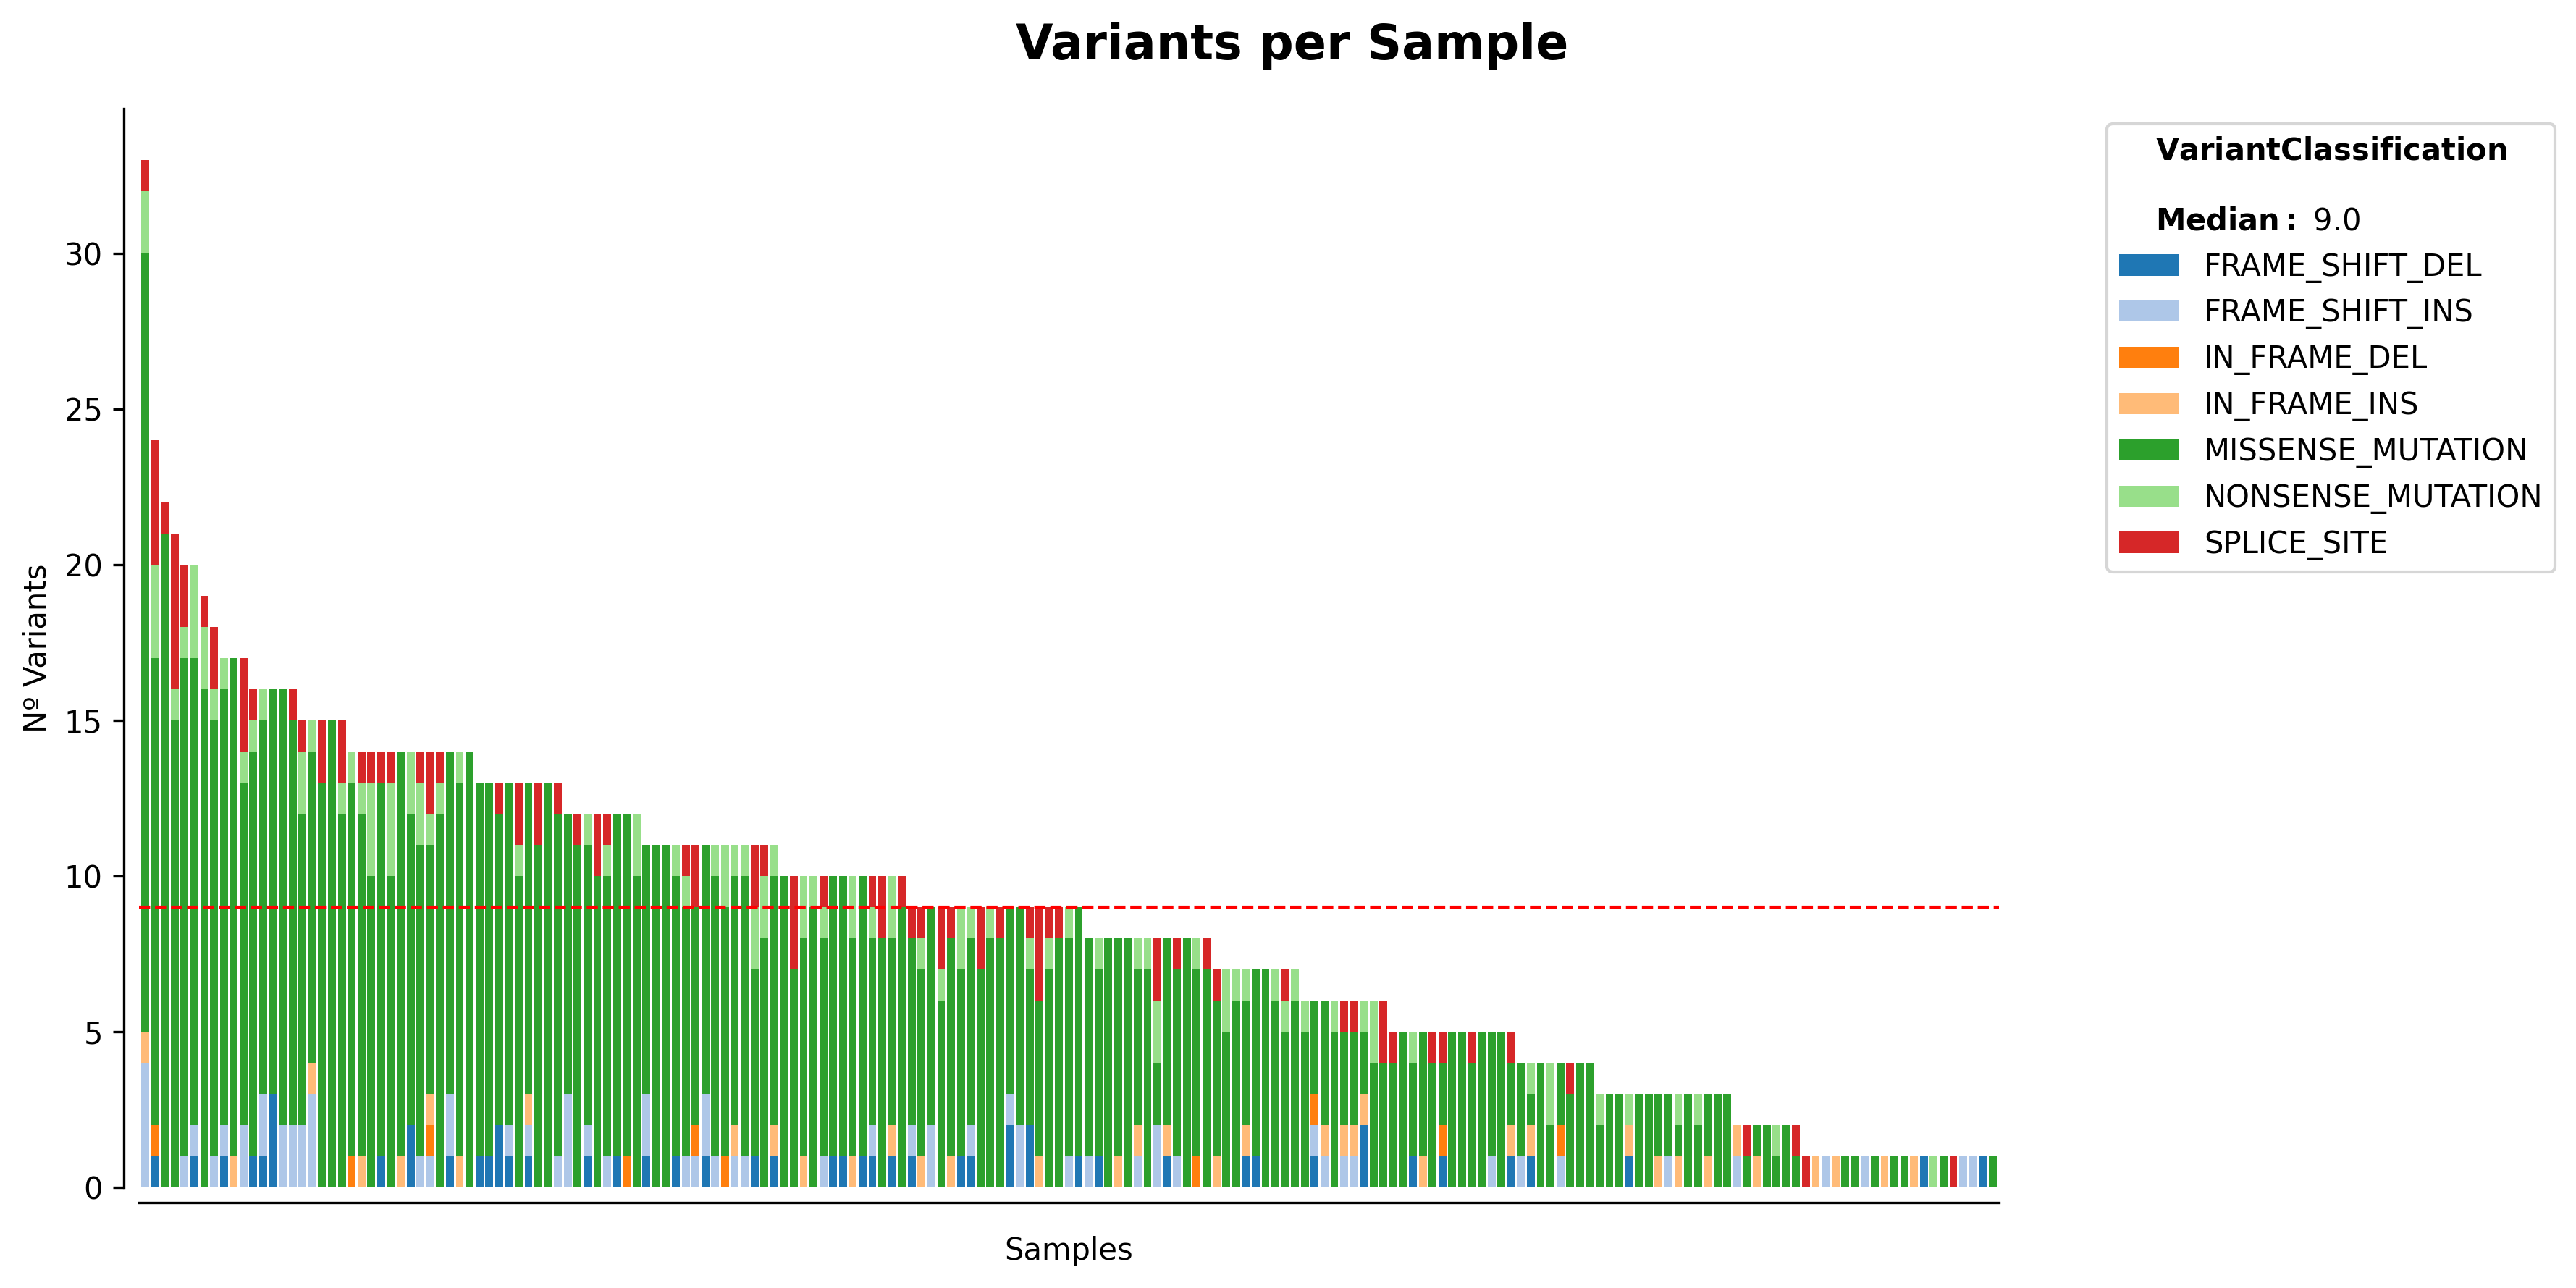

In [11]:
py_mutation.variants_per_sample_plot()

### Variant Classification Summary

Boxplots showing the distribution of per-sample variant counts for each classification type. Ordered by total count (most common first).

**Note:** By default, this plot excludes silent/synonymous mutations to match maftools behavior. Set `include_silent=True` to include them.

**Parameters:**

- `figsize`: Figure size. Default: `(10, 6)`
- `title`: Plot title. Default: `"Variant Classification Summary"`
- `include_silent`: Whether to include silent mutations. Default: `False`

2026-01-12 20:06:54,108 | INFO | pyMut.core | Generating variant classification summary plot...
2026-01-12 20:06:54,223 | INFO | pyMut.core | Variant classification summary plot generated in 0.11 seconds


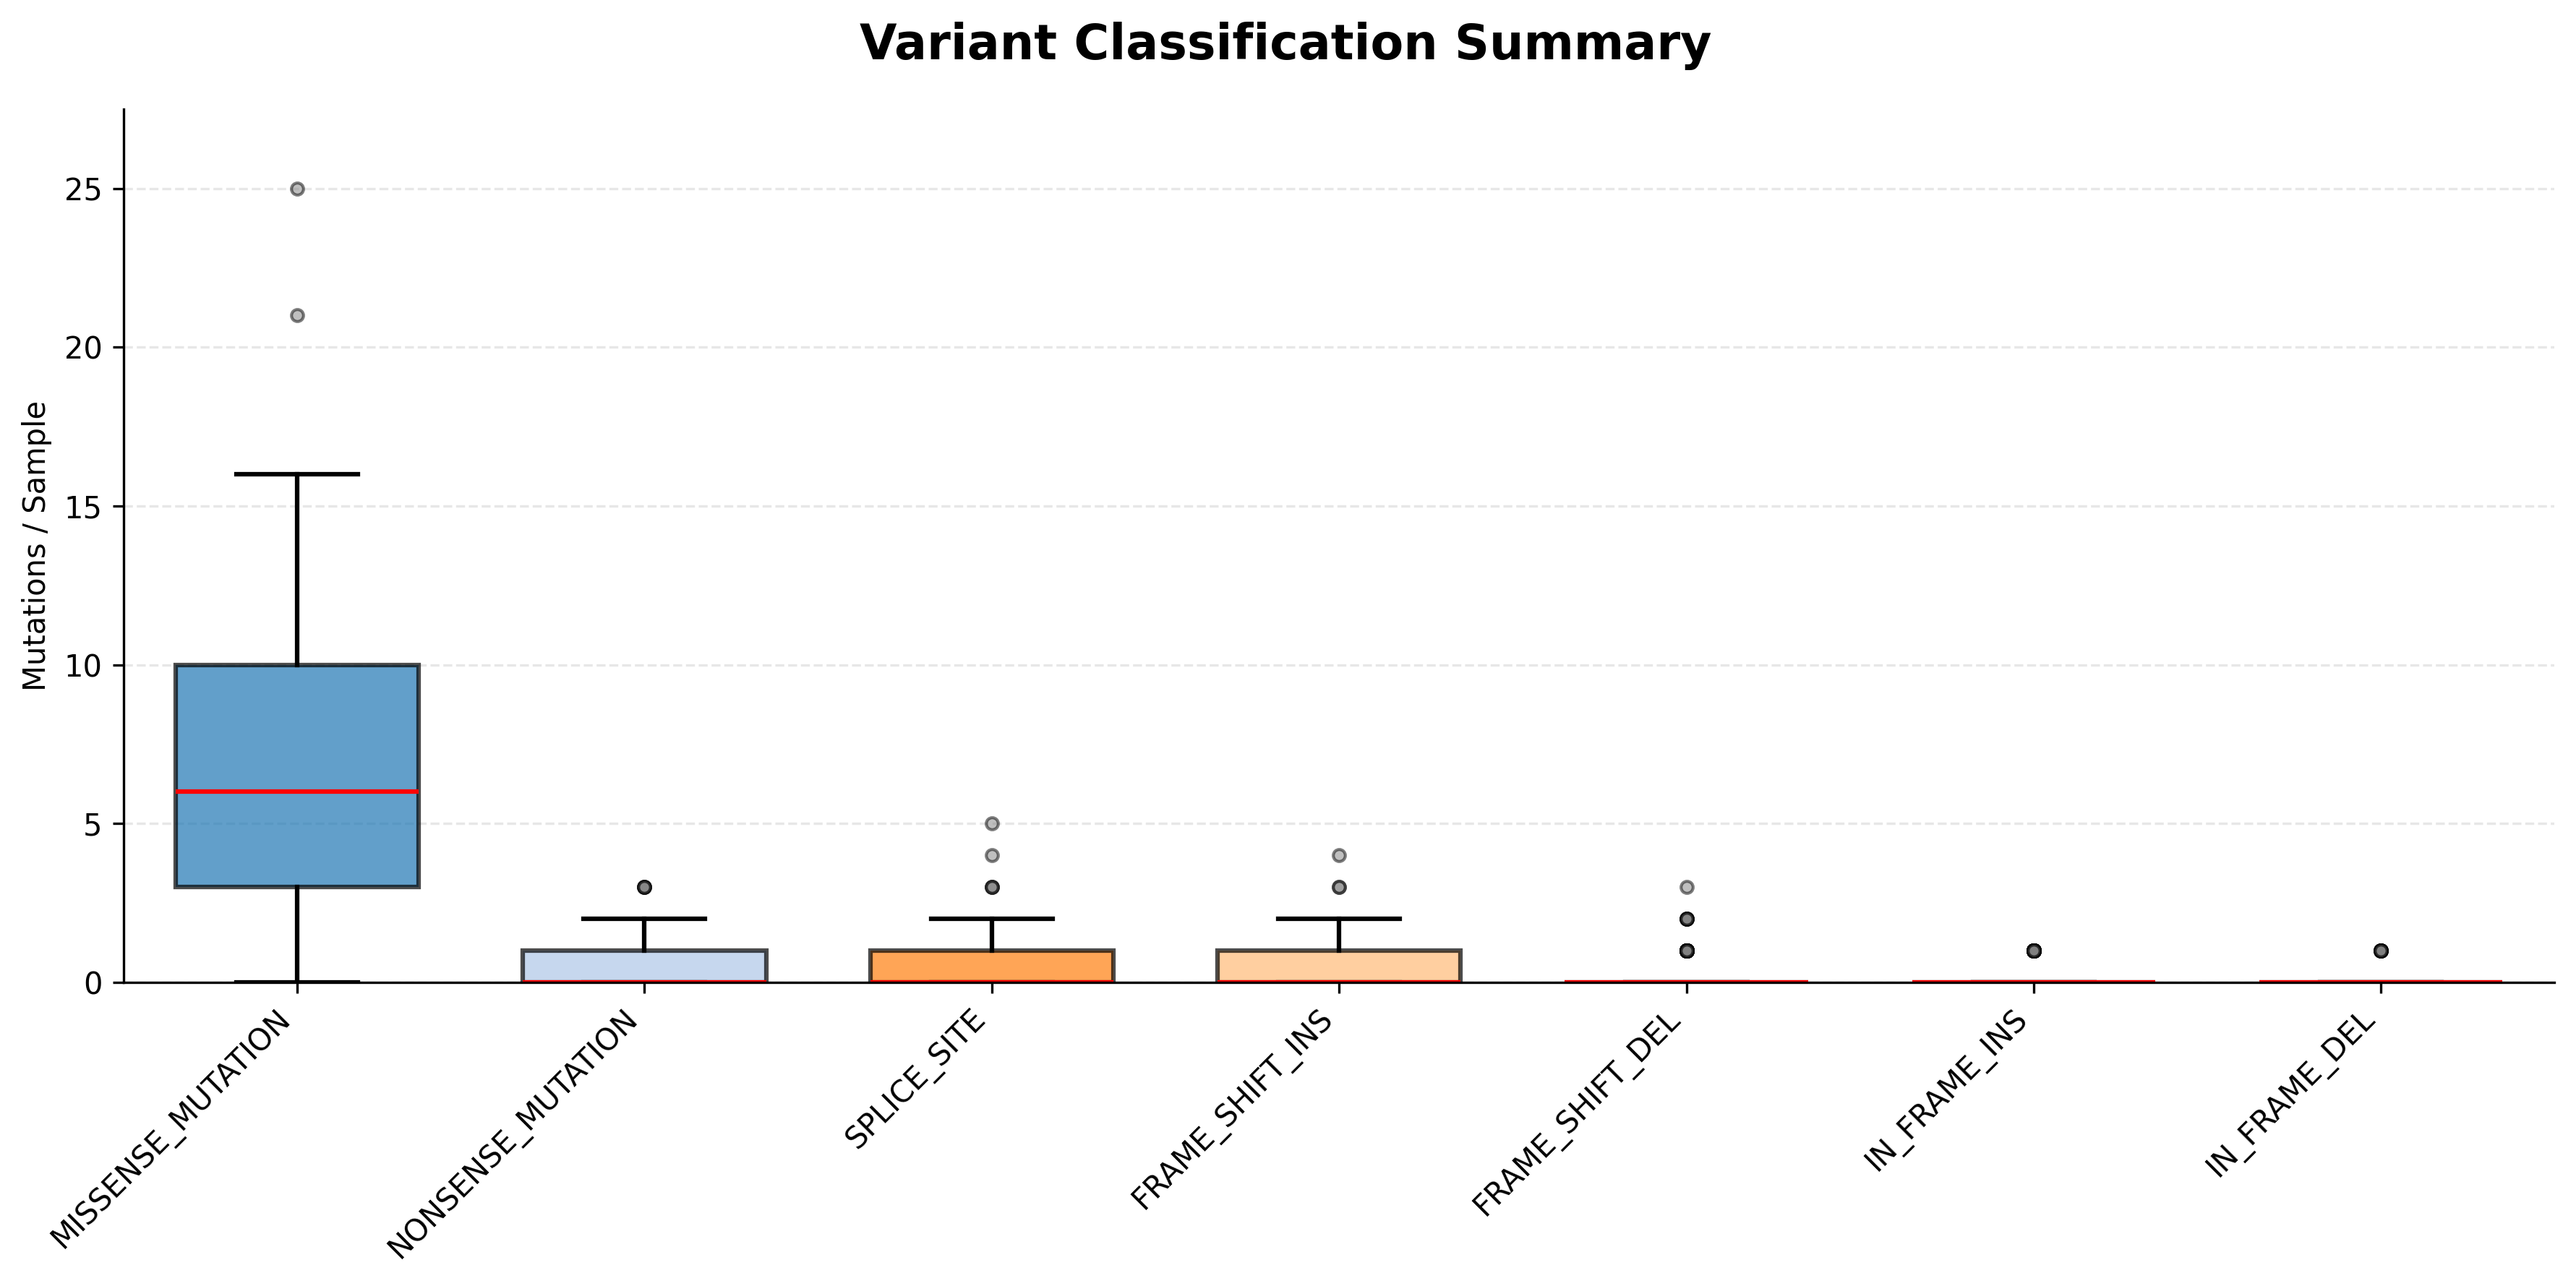

In [13]:
py_mutation.variant_classification_summary_plot()

### Top Mutated Genes

Horizontal stacked barplot showing the most frequently mutated genes. Two counting modes are available:

**Parameters:**

- `figsize`: Figure size. Default: `(10, 6)`
- `title`: Plot title. Default: `"Top Mutated Genes"`
- `top_genes_count`: Number of genes to display. Default: `10`
- `mode`: Counting mode. Options:
    - `"samples"`: Count distinct samples with at least one variant per gene (shows percentage)
    - `"variants"`: Count total variants per gene (default)

2026-01-12 20:06:54,656 | INFO | pyMut.core | Generating top mutated genes plot (mode=samples, count=10)...
2026-01-12 20:11:03,517 | INFO | pyMut.core | Top mutated genes plot generated in 248.86 seconds


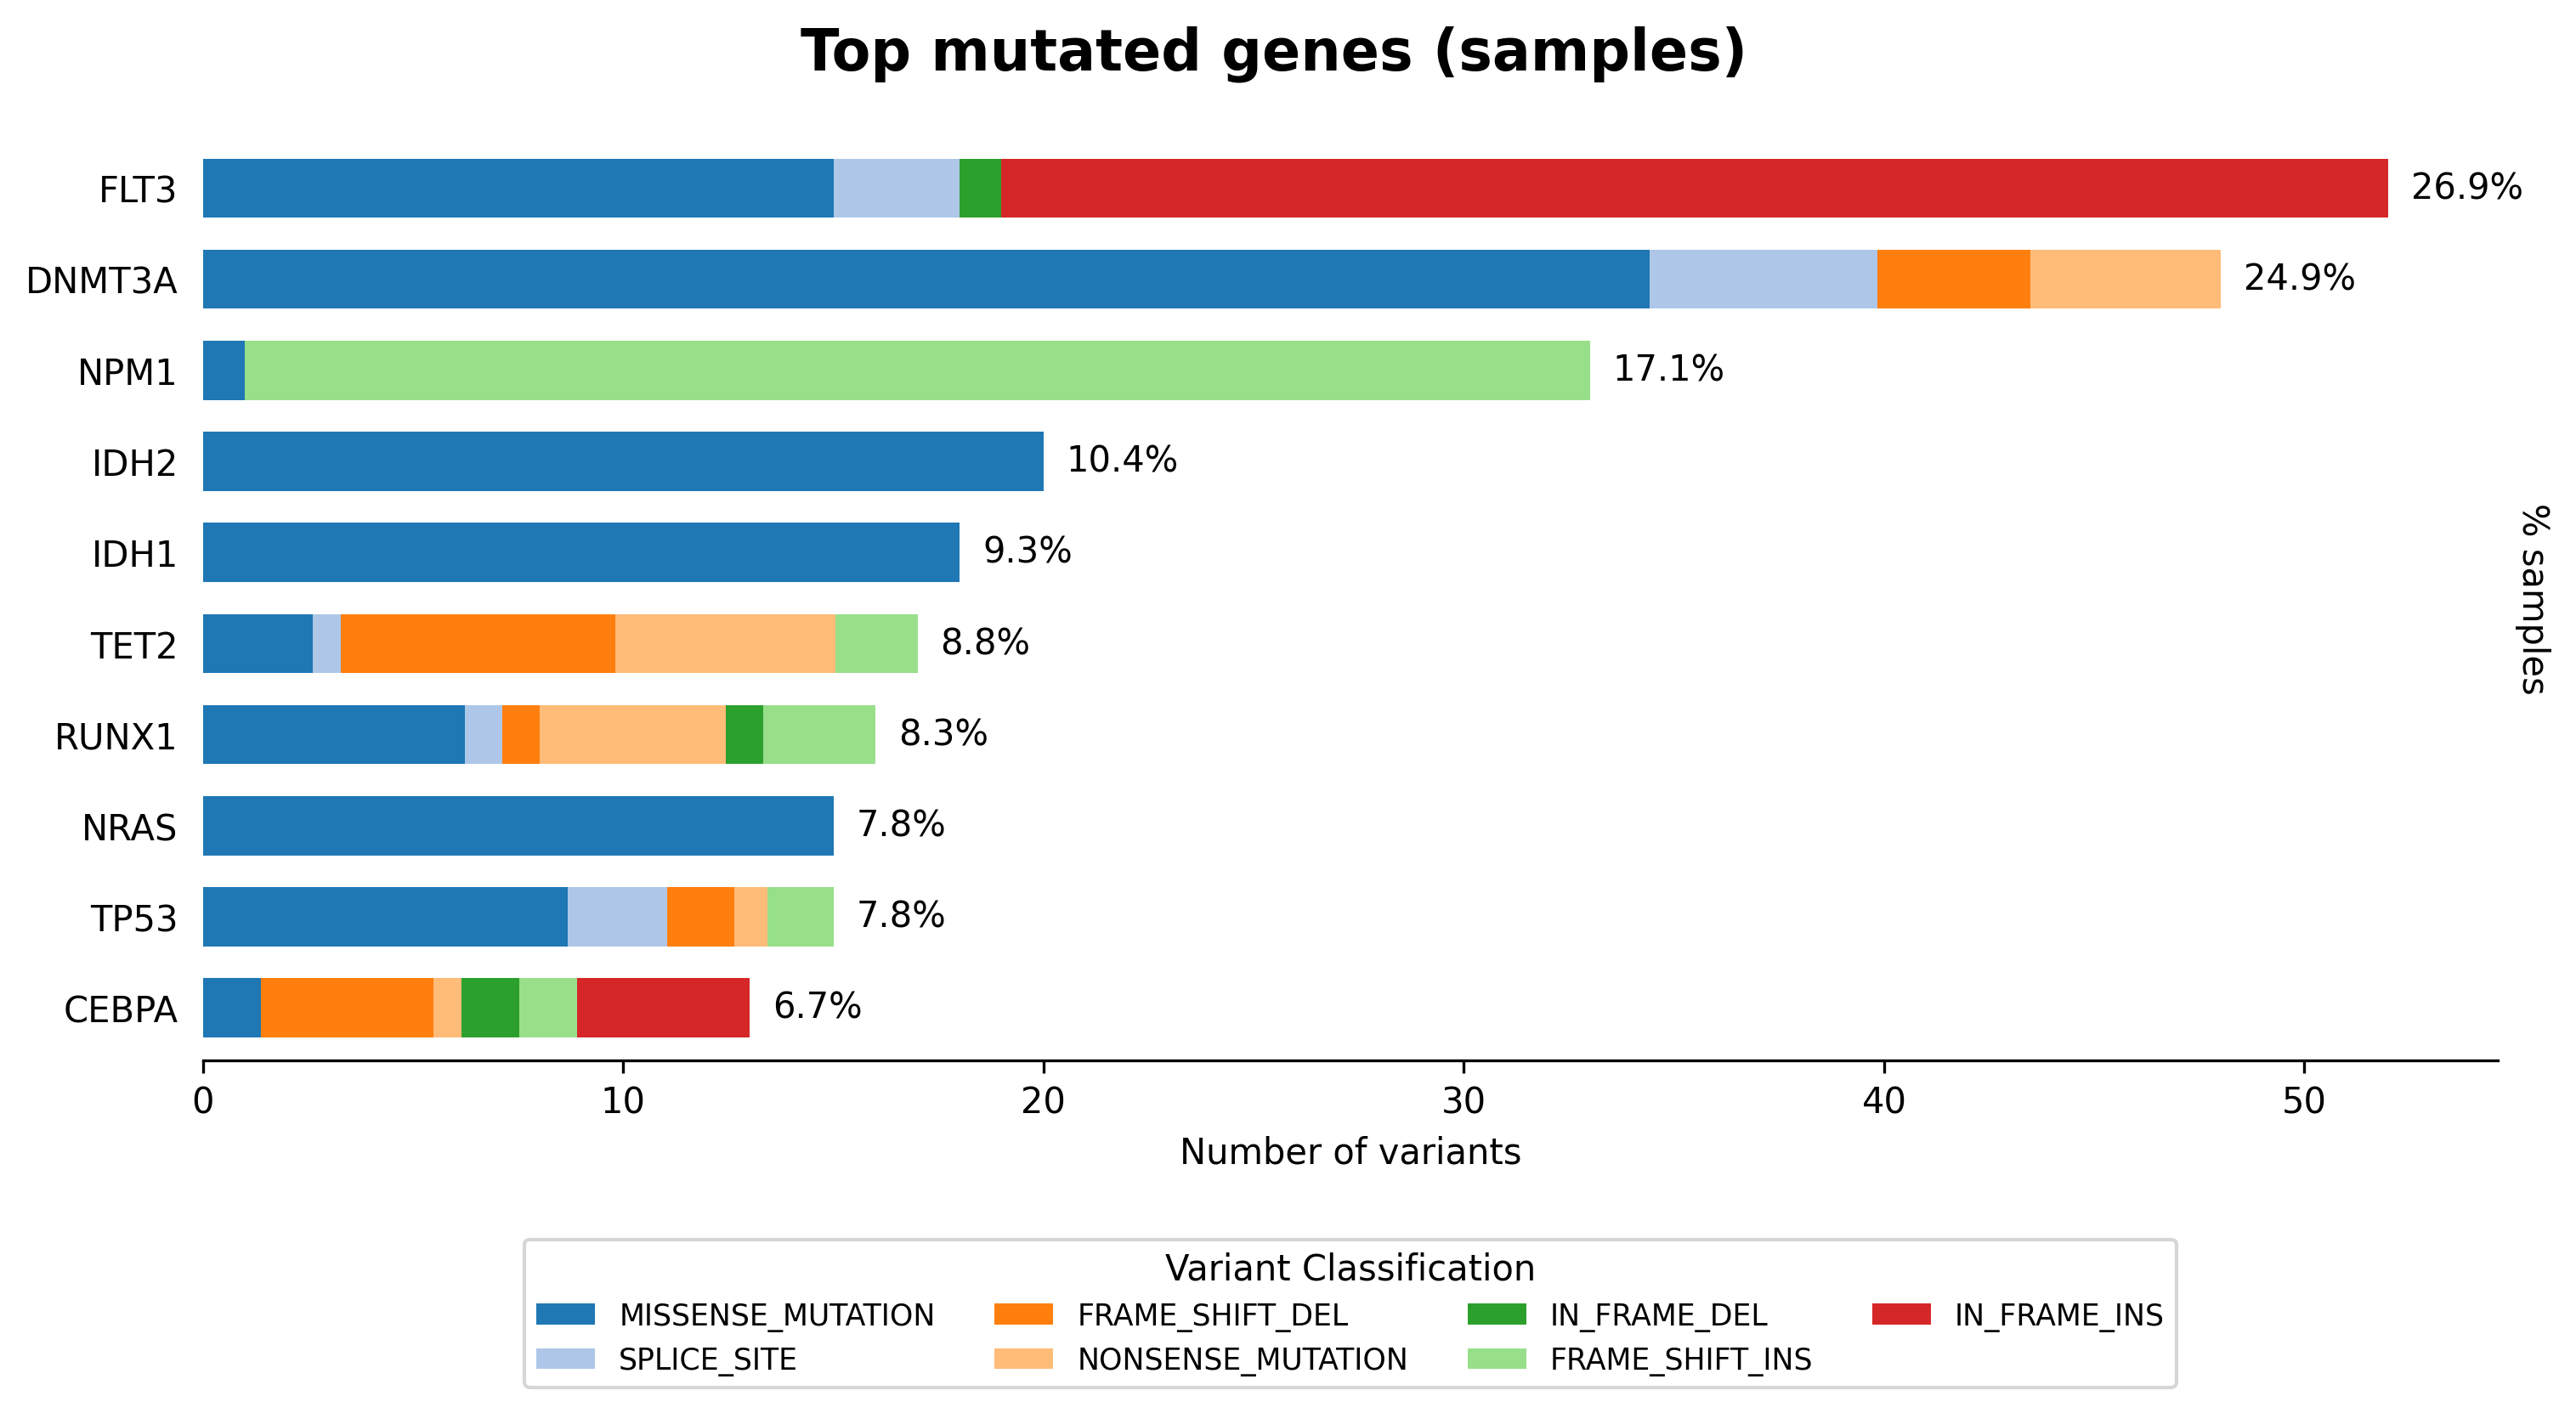

In [15]:
py_mutation.top_mutated_genes_plot(mode="samples")

Using `mode="variants"` to count total mutations per gene:

2026-01-12 20:15:54,791 | INFO | pyMut.core | Generating top mutated genes plot (mode=variants, count=10)...
2026-01-12 20:16:01,008 | INFO | pyMut.core | Top mutated genes plot generated in 6.22 seconds


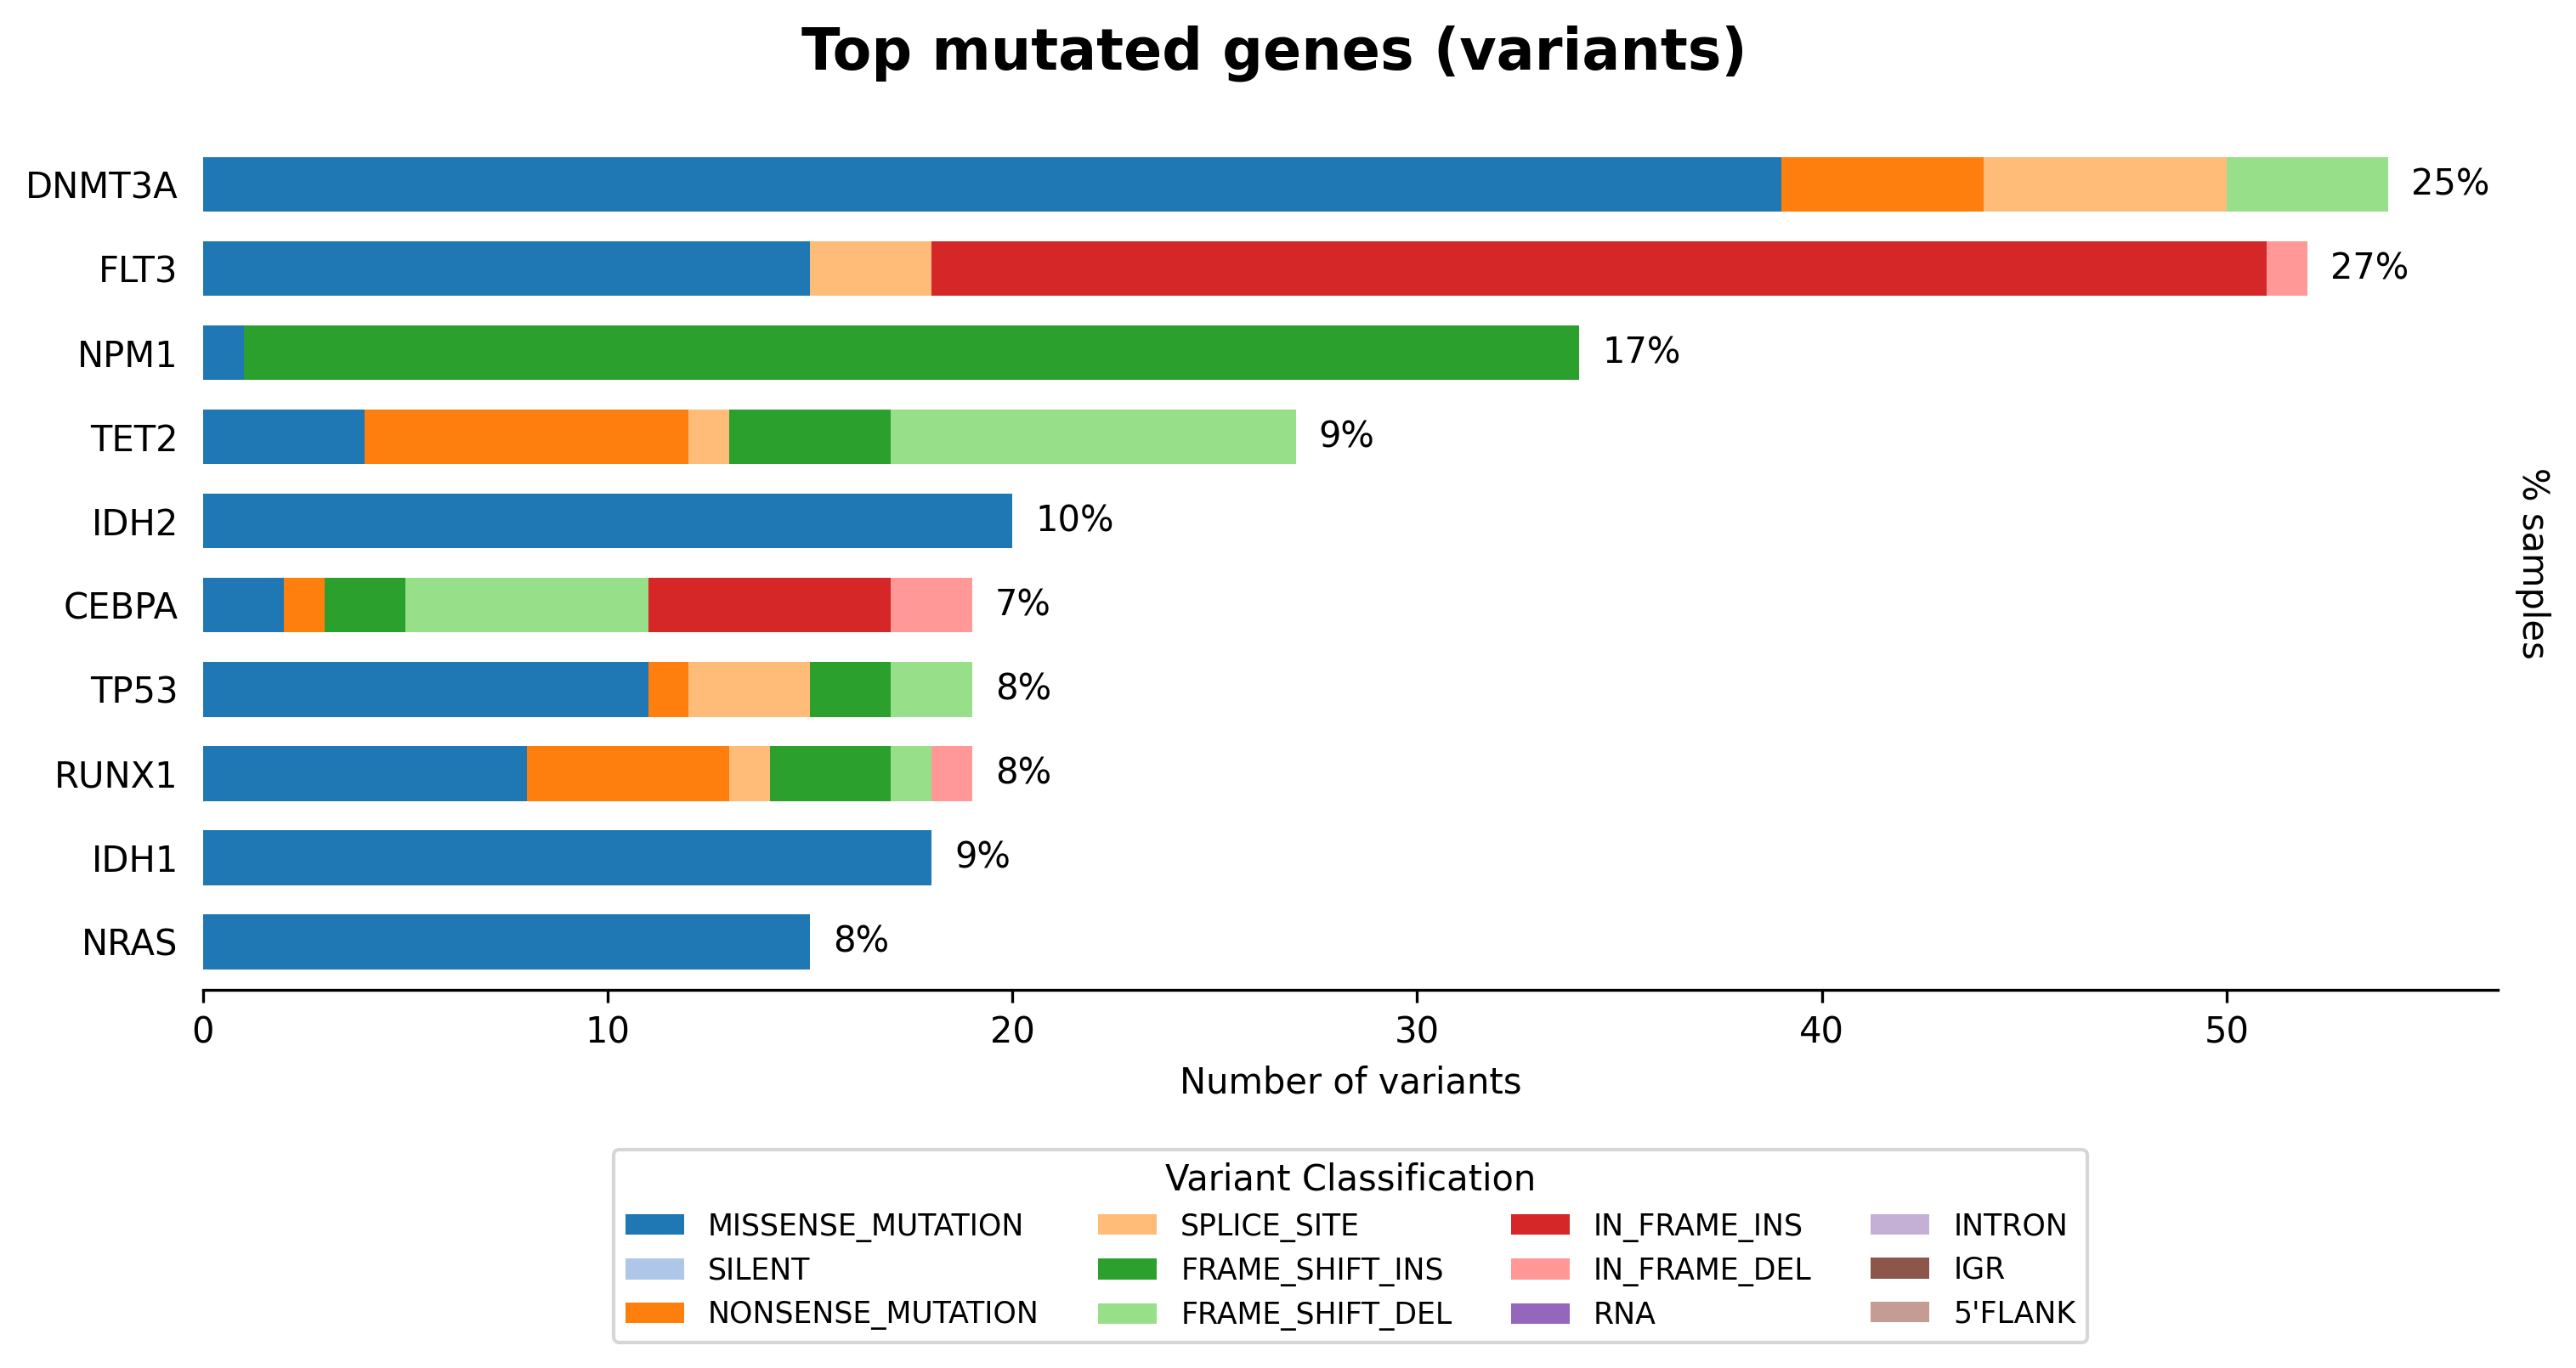

In [17]:
py_mutation.top_mutated_genes_plot(mode="variants")